In [3]:
#@title Prompt
# "Create a colab notebook illustrating GPU performance options for DNNs using GELU as an example with the following sections:
# 1) Native Python: the textbook GELU formula using CPU array
# 2) PyTorch module: uses tensors
# 3) torch.compile: compile #2
# 4) Built-in torch.nn.GELU
# 5) CUDA C++: raw kernel via PyCUDA
# 6) Triton: hand-written Triton kernel
# 7) Performance comparison between 1-6"

---
## Section 0: Setup

In [4]:
#@title setup
import torch
import torch.nn as nn
import numpy as np
import warnings
warnings.filterwarnings('ignore')

!pip install ninja

assert torch.cuda.is_available(), "GPU not found! Go to Runtime → Change runtime type → A100 GPU"
GPU_NAME = torch.cuda.get_device_name(0)
print(f"GPU: {GPU_NAME}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 5.5 MB/s eta 0:00:00
GPU: NVIDIA A100-SXM4-40GB
PyTorch: 2.10.0+cu128
CUDA: 12.8


# 1) Python GPU function

In [5]:
import math

def gelu_python(x):
    # NO GPU
    return 0.5 * x * (1 + math.tanh(
        math.sqrt(2.0 / math.pi) *
        (x + 0.044715 * (x ** 3))
    ))

print (gelu_python(1.0))

0.8411919906082768


In [6]:
inputs_list = [1.0, -1.0, 0.0, 2.0]

results_list = []
for val in inputs_list:
    result = gelu_python(val)
    results_list.append(result)

print(f"All results: {results_list}")

All results: [0.8411919906082768, -0.15880800939172324, 0.0, 1.954597694087775]


# 2) PyTorch module GELU

In [19]:
class CustomGeLU(nn.Module):
  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
        (x + 0.044715 * torch.pow(x, 3))
    ))

In [8]:
inputs = torch.tensor([1.0, -1.0, 0.0, 2.0],
                      device="cuda",
                      dtype=torch.float32)

custom_gelu = CustomGeLU().cuda()

print(custom_gelu(inputs))

tensor([ 0.8412, -0.1588,  0.0000,  1.9546], device='cuda:0')


# 3) PyTorch module GELU + torch.compile()

In [9]:
compiled_gelu = torch.compile(
      CustomGeLU().cuda(),
      mode="max-autotune")

print(compiled_gelu(inputs))

tensor([ 0.8412, -0.1588,  0.0000,  1.9546], device='cuda:0')


# 4) Built-in torch.nn.GELU

In [10]:
builtin_gelu = nn.GELU().cuda()

print(builtin_gelu(inputs))

tensor([ 0.8413, -0.1587,  0.0000,  1.9545], device='cuda:0')


# 5) CUDA C++ Kernel

In [11]:
import torch
import torch.nn as nn
from torch.utils.cpp_extension import load_inline
import os

# Ensure ninja is used for building
os.environ['NINJA_BUILD'] = '1'

cuda_source = """
#include <torch/extension.h>
#include <cuda.h>
#include <cuda_runtime.h>

__global__ void fused_gelu_f32(float *out, const float *x, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        float v = x[idx];
        float cube = v * v * v;
        float inner = sqrtf(2.0f / 3.14159265358979f) * (v + 0.044715f * cube);
        float t = tanhf(inner);
        out[idx] = 0.5f * v * (1.0f + t);
    }
}

torch::Tensor cuda_gelu(torch::Tensor x) {
    auto out = torch::empty_like(x);
    int n = x.numel();
    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    fused_gelu_f32<<<blocks, threads>>>(
        out.data_ptr<float>(),
        x.data_ptr<float>(),
        n
    );

    return out;
}
"""

cpp_source = """
torch::Tensor cuda_gelu(torch::Tensor x);
"""

cuda_module = load_inline(
    name="custom_gelu",
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=["cuda_gelu"],
    with_cuda=True,
    extra_cflags=["-O3"],
    extra_cuda_cflags=["-O3"]
)

class CudaGELU(nn.Module):
    def forward(self, x):
        return cuda_module.cuda_gelu(x)


In [12]:
cuda_gelu = CudaGELU().cuda()

print(cuda_gelu(inputs))

tensor([ 0.8412, -0.1588,  0.0000,  1.9546], device='cuda:0')


# 6) Triton Kernel

In [13]:
import triton
import triton.language as tl

@triton.jit
def gelu_triton_kernel(x_ptr, out_ptr, n_elements, BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(0)
    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements

    x = tl.load(x_ptr + offsets, mask=mask)

    cube = x * x * x
    inner = tl.sqrt(2.0 / 3.14159265358979) * (x + 0.044715 * cube)
    result = 0.5 * x * (1.0 + tl.extra.cuda.libdevice.tanh(inner))

    tl.store(out_ptr + offsets, result, mask=mask)


class TritonGELU(nn.Module):
    def forward(self, x):
        out = torch.empty_like(x)
        n = x.numel()
        grid = lambda meta: (triton.cdiv(n, meta['BLOCK_SIZE']),)
        gelu_triton_kernel[grid](x, out, n, BLOCK_SIZE=1024)
        return out

In [14]:
triton_gelu = TritonGELU().cuda()

print(triton_gelu(inputs))

tensor([ 0.8412, -0.1588,  0.0000,  1.9546], device='cuda:0')


---
## Section 7: Performance Comparison

Correctness check (max abs error vs built-in):
  custom module:  1.53e-04
  Compiled:       1.53e-04
  Triton:         1.53e-04
  CUDA C++:       1.53e-04

── Tensor size: 32K (32,768 elements) ──
  PyTorch custom module      median:   0.1505 ms  |  mean:   0.1568 ms  |  min:   0.1382 ms
  torch.compile              median:   0.1556 ms  |  mean:   0.1581 ms  |  min:   0.1434 ms
  torch.nn.GELU              median:   0.0266 ms  |  mean:   0.0272 ms  |  min:   0.0256 ms
  CUDA C++                   median:   0.0236 ms  |  mean:   0.0239 ms  |  min:   0.0215 ms
  Triton                     median:   0.0502 ms  |  mean:   0.0517 ms  |  min:   0.0481 ms

── Tensor size: 256K (262,144 elements) ──
  PyTorch custom module      median:   0.1434 ms  |  mean:   0.1467 ms  |  min:   0.1372 ms
  torch.compile              median:   0.1536 ms  |  mean:   0.1549 ms  |  min:   0.1413 ms
  torch.nn.GELU              median:   0.0266 ms  |  mean:   0.0278 ms  |  min:   0.0256 ms
  CUDA C++             

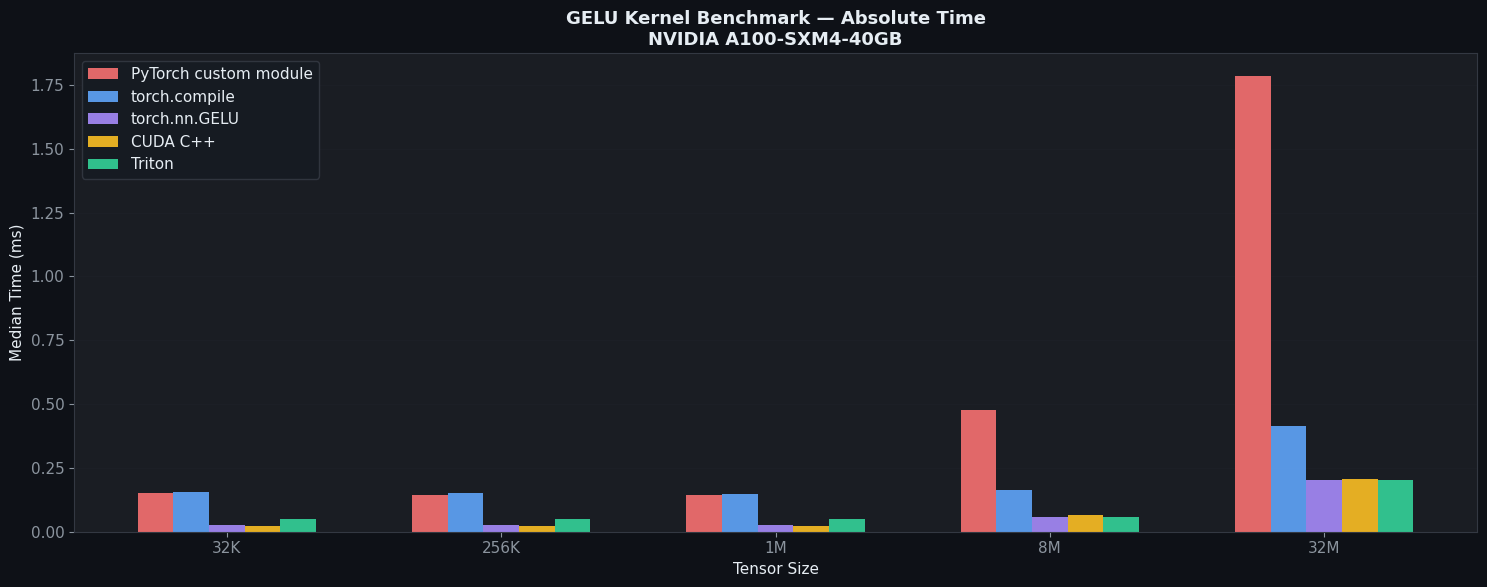

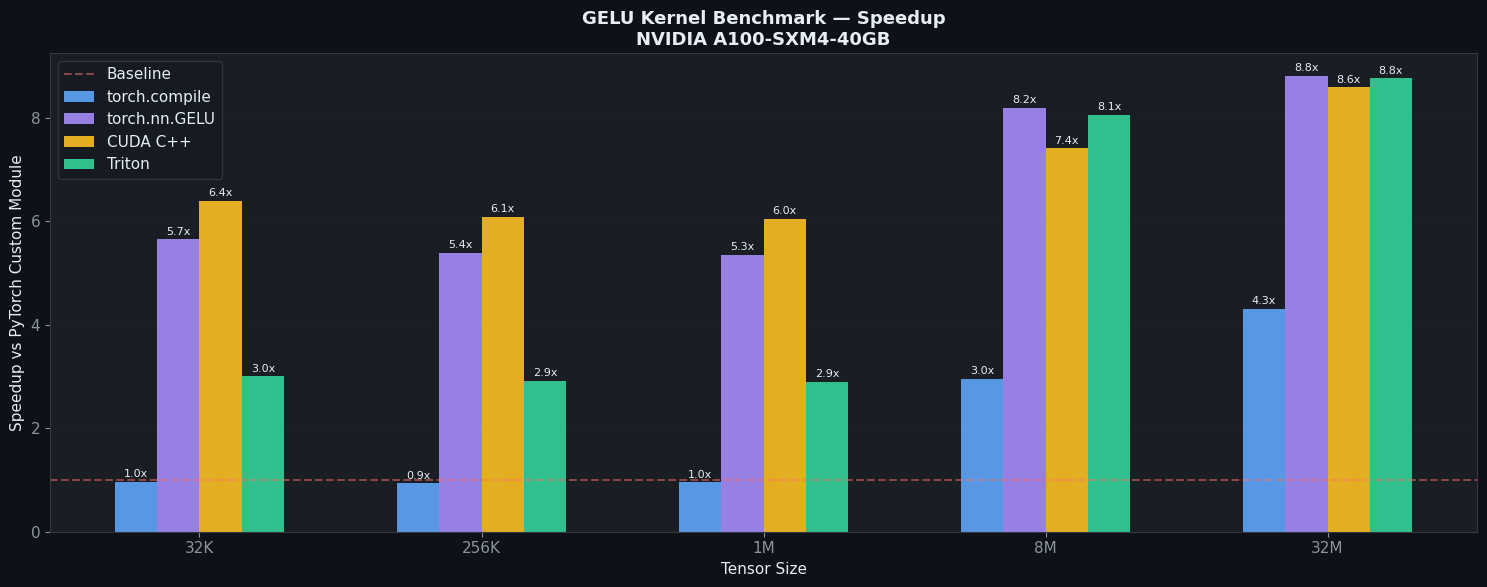

In [15]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#1a1d23',
    'axes.edgecolor': '#333842',
    'axes.labelcolor': '#e6edf3',
    'text.color': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'grid.color': '#21262d',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#333842',
})

def benchmark(fn, x, warmup=20, rep=100, label=""):
    for _ in range(warmup):
        fn(x)
    torch.cuda.synchronize()

    start_events = [torch.cuda.Event(enable_timing=True) for _ in range(rep)]
    end_events   = [torch.cuda.Event(enable_timing=True) for _ in range(rep)]

    for i in range(rep):
        start_events[i].record()
        fn(x)
        end_events[i].record()
    torch.cuda.synchronize()

    times = [s.elapsed_time(e) for s, e in zip(start_events, end_events)]
    median_ms = sorted(times)[rep // 2]
    mean_ms   = sum(times) / len(times)
    min_ms    = min(times)

    print(f"  {label:<25s}  median: {median_ms:8.4f} ms  |  mean: {mean_ms:8.4f} ms  |  min: {min_ms:8.4f} ms")
    return median_ms

# --- Correctness check ---
print("Correctness check (max abs error vs built-in):")
ref = builtin_gelu(inputs)
def get_err(out): return (out - ref).abs().max().item()

print(f"  custom module:  {get_err(custom_gelu(inputs)):.2e}")
print(f"  Compiled:       {get_err(compiled_gelu(inputs)):.2e}")
print(f"  Triton:         {get_err(triton_gelu(inputs)):.2e}")
print(f"  CUDA C++:       {get_err(cuda_gelu(inputs)):.2e}")
print()

# --- Benchmark across tensor sizes ---
sizes = [
    ("32K",    32 * 1024),
    ("256K",   256 * 1024),
    ("1M",     1024 * 1024),
    ("8M",     8 * 1024 * 1024),
    ("32M",    32 * 1024 * 1024),
]

# Aligning names and functions
impl_names = ["PyTorch custom module", "torch.compile", "torch.nn.GELU", "CUDA C++", "Triton"]
impl_fns   = [custom_gelu, compiled_gelu, builtin_gelu, cuda_gelu, triton_gelu]

results = {}
for size_label, n in sizes:
    x = torch.randn(n, device="cuda", dtype=torch.float32)
    print(f"── Tensor size: {size_label} ({n:,} elements) ──")
    results[size_label] = {}
    for name, fn in zip(impl_names, impl_fns):
        t = benchmark(fn, x, label=name)
        results[size_label][name] = t
    print()

# --- Speedup table ---
print("── Speedup vs PyTorch custom module (median time) ──")
header = f"  {'Size':<10s}"
for name in impl_names[1:]:
    header += f"  {name:>16s}"
print(header)
for size_label, timings in results.items():
    baseline_t = timings["PyTorch custom module"]
    row = f"  {size_label:<10s}"
    for name in impl_names[1:]:
        row += f"  {baseline_t / timings[name]:>15.2f}x"
    print(row)

# --- Plots ---
colors = {
    "PyTorch custom module":  "#f87171",
    "torch.compile":  "#60a5fa",
    "Triton":         "#34d399",
    "CUDA C++":       "#fbbf24",
    "torch.nn.GELU":  "#a78bfa",
}

size_labels = list(results.keys())
n_sizes = len(size_labels)
n_impls = len(impl_names)
x_pos = np.arange(n_sizes)

fig1, ax1 = plt.subplots(figsize=(15, 6))
bar_width = 0.13
for i, name in enumerate(impl_names):
    times = [results[s][name] for s in size_labels]
    offset = (i - n_impls / 2 + 0.5) * bar_width
    ax1.bar(x_pos + offset, times, bar_width,
            label=name, color=colors[name], edgecolor='none', alpha=0.9)

ax1.set_xlabel("Tensor Size")
ax1.set_ylabel("Median Time (ms)")
ax1.set_title(f"GELU Kernel Benchmark — Absolute Time\n{GPU_NAME}", fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(size_labels)
ax1.legend(loc='upper left', framealpha=0.9)
ax1.grid(axis='y', alpha=0.3)
ax1.set_axisbelow(True)
fig1.tight_layout()
fig1.savefig("gelu_benchmark_absolute.png", dpi=150, bbox_inches='tight')

fig2, ax2 = plt.subplots(figsize=(15, 6))
fused_names = impl_names[1:]
n_fused = len(fused_names)
bar_width2 = 0.15

for i, name in enumerate(fused_names):
    speedups = [results[s]["PyTorch custom module"] / results[s][name] for s in size_labels]
    offset = (i - n_fused / 2 + 0.5) * bar_width2
    bars = ax2.bar(x_pos + offset, speedups, bar_width2,
                   label=name, color=colors[name], edgecolor='none', alpha=0.9)
    for bar, val in zip(bars, speedups):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:.1f}x', ha='center', va='bottom', fontsize=8, color='#e6edf3')

ax2.axhline(y=1.0, color='#f87171', linestyle='--', alpha=0.5, label='Baseline')
ax2.set_xlabel("Tensor Size")
ax2.set_ylabel("Speedup vs PyTorch Custom Module")
ax2.set_title(f"GELU Kernel Benchmark — Speedup\n{GPU_NAME}", fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(size_labels)
ax2.legend(loc='upper left', framealpha=0.9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_axisbelow(True)
fig2.tight_layout()
fig2.savefig("gelu_benchmark_speedup.png", dpi=150, bbox_inches='tight')

plt.show()

In [16]:
import matplotlib.pyplot as plt


ref = builtin_gelu(inputs)
def get_err(out): return (out - ref).abs().max().item()

print("Correctness check (max abs error vs built-in):")
print(f"  custom module:  {get_err(custom_gelu(inputs)):.2e}")
print(f"  Compiled:       {get_err(compiled_gelu(inputs)):.2e}")
print(f"  Triton:         {get_err(triton_gelu(inputs)):.2e}")
print(f"  CUDA C++:       {get_err(cuda_gelu(inputs)):.2e}")
print()

plt.show()

Starting GELU Benchmark Execution...
Correctness check (max abs error vs built-in):
  custom module:  1.53e-04
  Compiled:       1.53e-04
  Triton:         1.53e-04
  CUDA C++:       1.53e-04



── Tensor size: 32K (32,768 elements) ──
  PyTorch custom module      median:   0.1464 ms  |  mean:   0.1486 ms  |  min:   0.1382 ms
  torch.compile              median:   0.1567 ms  |  mean:   0.1578 ms  |  min:   0.1444 ms
  torch.nn.GELU              median:   0.0266 ms  |  mean:   0.0280 ms  |  min:   0.0256 ms
  CUDA C++                   median:   0.0236 ms  |  mean:   0.0241 ms  |  min:   0.0225 ms
  Triton                     median:   0.0502 ms  |  mean:   0.0519 ms  |  min:   0.0481 ms

── Tensor size: 256K (262,144 elements) ──
  PyTorch custom module      median:   0.1434 ms  |  mean:   0.1470 ms  |  min:   0.1382 ms
  torch.compile              median:   0.2048 ms  |  mean:   0.2078 ms  |  min:   0.1536 ms
  torch.nn.GELU              median:   0.0276 ms  |  mean:   0.0342 ms  |  min:   0.0256 ms
  CUDA C++                   median:   0.0236 ms  |  mean:   0.0251 ms  |  min:   0.0225 ms
  Triton                     median:   0.0502 ms  |  mean:   0.0532 ms  |  min:   0.048

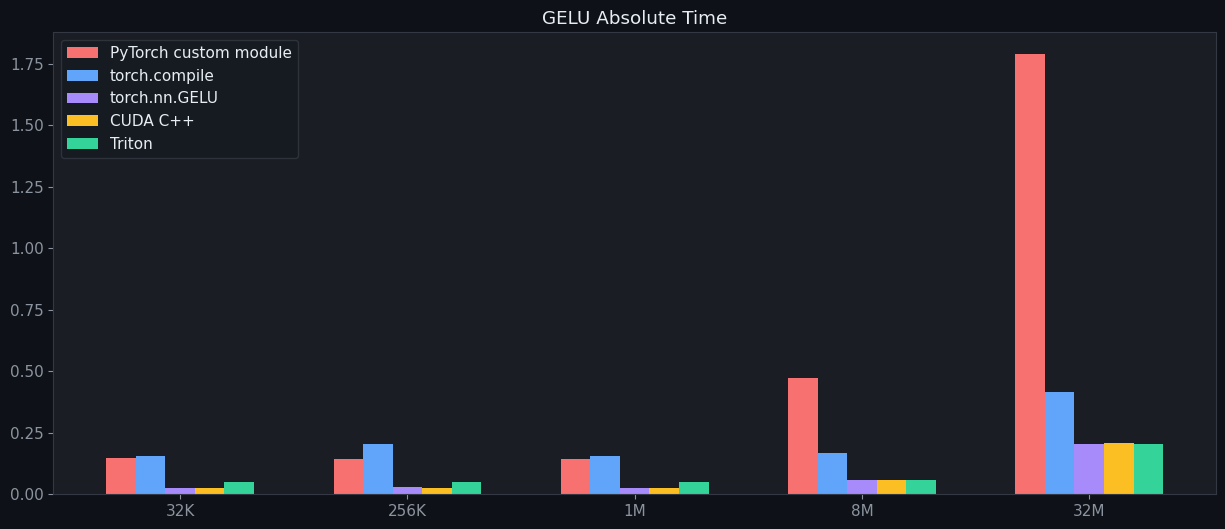

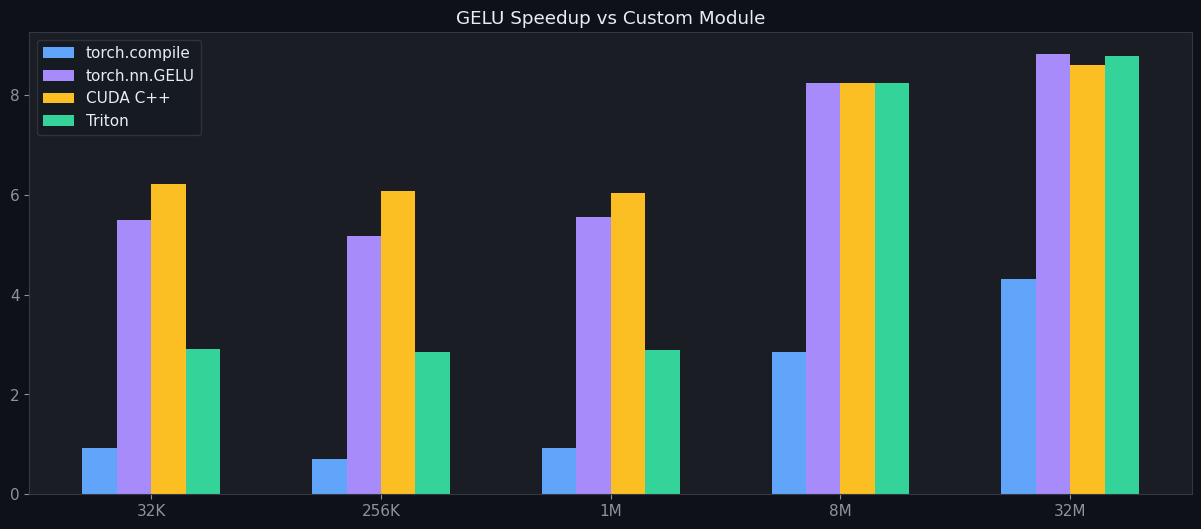

In [17]:
results = {}
for size_label, n in sizes:
    x = torch.randn(n, device='cuda', dtype=torch.float32)
    print(f'── Tensor size: {size_label} ({n:,} elements) ──')
    results[size_label] = {}
    for name, fn in zip(impl_names, impl_fns):
        t = benchmark(fn, x, label=name)
        results[size_label][name] = t
    print()

print('── Speedup vs PyTorch custom module (median time) ──')
header = f'  {"Size":<10s}'
for name in impl_names[1:]:
    header += f'  {name:>16s}'
print(header)
for size_label, timings in results.items():
    baseline_t = timings['PyTorch custom module']
    row = f'  {size_label:<10s}'
    for name in impl_names[1:]:
        row += f'  {baseline_t / timings[name]:>15.2f}x'
    print(row)

# Trigger plotting logic using existing variables in kernel
size_labels = list(results.keys())
x_pos = np.arange(len(size_labels))
fig1, ax1 = plt.subplots(figsize=(15, 6))
bar_width = 0.13
for i, name in enumerate(impl_names):
    times = [results[s][name] for s in size_labels]
    offset = (i - len(impl_names) / 2 + 0.5) * bar_width
    ax1.bar(x_pos + offset, times, bar_width, label=name, color=colors[name])
ax1.set_title('GELU Absolute Time')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(size_labels)
ax1.legend()
plt.show()

fig2, ax2 = plt.subplots(figsize=(15, 6))
fused_names = impl_names[1:]
for i, name in enumerate(fused_names):
    speedups = [results[s]['PyTorch custom module'] / results[s][name] for s in size_labels]
    offset = (i - len(fused_names) / 2 + 0.5) * 0.15
    ax2.bar(x_pos + offset, speedups, 0.15, label=name, color=colors[name])
ax2.set_title('GELU Speedup vs Custom Module')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(size_labels)
ax2.legend()
plt.show()

# 8) CPU vs. GPU

GELU on 33,554,432 elements

CPU (Python loop)...
  CPU:  11,015.7 ms
  GPU (torch.nn.GELU):  0.2028 ms

  GPU speedup: 54,331x faster


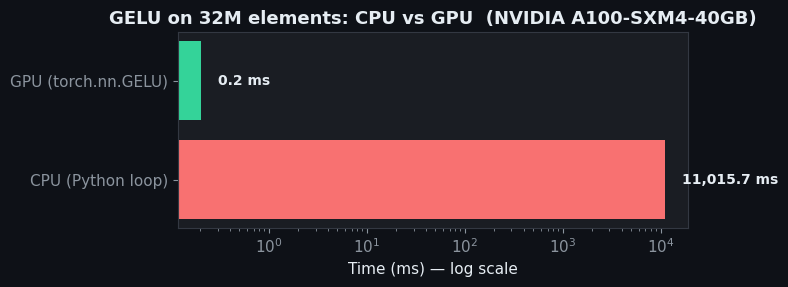


Python processes 32M GELU calls one at a time.
The GPU does all 32M in parallel across thousands of cores.
Result: 54,331x speedup.


In [18]:
import time

# --- CPU: Python loop over 32M elements ---
n = 32 * 1024 * 1024
x_cpu = [float(v) for v in torch.randn(n).numpy()]

print(f"GELU on {n:,} elements\n")

print("CPU (Python loop)...")
# warmup
for i in range(1000):
    gelu_python(x_cpu[i])

t0 = time.perf_counter()
cpu_results = [gelu_python(v) for v in x_cpu]
t1 = time.perf_counter()
cpu_ms = (t1 - t0) * 1000
print(f"  CPU:  {cpu_ms:,.1f} ms")

# --- GPU: fastest method from Section 7 ---
# Find which GPU impl was fastest at 32M
gpu_timings_32m = results["32M"]
fastest_name = min(gpu_timings_32m, key=gpu_timings_32m.get)
fastest_ms = gpu_timings_32m[fastest_name]
print(f"  GPU ({fastest_name}):  {fastest_ms:.4f} ms")

speedup = cpu_ms / fastest_ms
print(f"\n  GPU speedup: {speedup:,.0f}x faster")

# --- Chart ---
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(
    [f"GPU ({fastest_name})", "CPU (Python loop)"],
    [fastest_ms, cpu_ms],
    color=["#34d399", "#f87171"]
)
ax.set_xscale("log")
ax.set_xlabel("Time (ms) — log scale")
ax.set_title(f"GELU on 32M elements: CPU vs GPU  ({GPU_NAME})", fontsize=13, fontweight="bold")
for bar, t in zip(bars, [fastest_ms, cpu_ms]):
    ax.text(t * 1.5, bar.get_y() + bar.get_height()/2,
            f"{t:,.1f} ms", va="center", fontsize=10, fontweight="bold")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

print(f"\nPython processes 32M GELU calls one at a time.")
print(f"The GPU does all 32M in parallel across thousands of cores.")
print(f"Result: {speedup:,.0f}x speedup.")

# 9) Comparing custom modules with/without Compile

CustomGeLU (eager):    5 distinct ops, 9 total calls
    aten::mul ×4
    aten::sqrt ×1
    aten::pow ×1
    aten::add ×2
    aten::tanh ×1

compiled_gelu:         1 ops (compile may have fallen back to eager)
    aten::_foreach_copy_ ×1

── Eager mode kernel details ──
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                  aten::mul         3.39%     104.576us        94.26%       2.905ms     726.199us             4  
    Activity Buffer Request        70.00%       2.157ms        70.00%       2.157ms       2.157ms             1  
           cudaLaunchKernel        22.22%     684.644us        22.22%     684.644us      85.581us             8  
                aten::empty         0.21%    

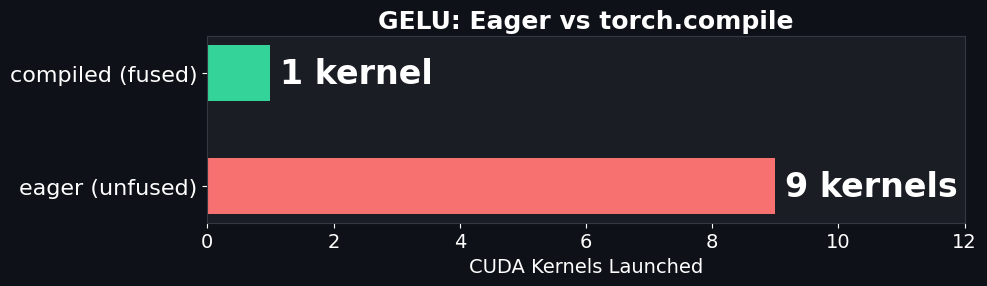

In [29]:
#@title Kernel count: eager vs compiled
from torch.profiler import profile, ProfilerActivity
import torch._dynamo
import torch._inductor.config

# Force clean recompilation without CUDA graphs
torch._dynamo.reset()
torch._inductor.config.triton.cudagraphs = False

compiled_gelu_nograph = torch.compile(CustomGeLU().cuda(), mode="max-autotune")

x = torch.randn(1024, device="cuda", dtype=torch.float32)

# Multiple warmup calls to ensure compilation actually triggers
for _ in range(5):
    compiled_gelu_nograph(x)
torch.cuda.synchronize()

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof_eager:
    custom_gelu(x)
torch.cuda.synchronize()

with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as prof_compiled:
    compiled_gelu_nograph(x)
torch.cuda.synchronize()

# Count compute ops from the aten:: calls (the real work)
def get_compute_ops(prof):
    compute = []
    for e in prof.key_averages():
        if e.key.startswith("aten::") and e.key not in ("aten::empty", "aten::to", "aten::lift_fresh", "aten::detach_", "aten::result_type"):
            compute.append((e.key, e.count))
    return compute

eager_ops = get_compute_ops(prof_eager)
compiled_ops = get_compute_ops(prof_compiled)

# Check if compiled actually fused (should have triton_ kernel)
has_triton = any("triton" in e.key for e in prof_compiled.key_averages())

print(f"CustomGeLU (eager):    {len(eager_ops)} distinct ops, {sum(c for _,c in eager_ops)} total calls")
for name, count in eager_ops:
    print(f"    {name} ×{count}")
print()

if has_triton:
    triton_kernels = [(e.key, e.count) for e in prof_compiled.key_averages() if "triton" in e.key]
    print(f"compiled_gelu:         {len(triton_kernels)} fused kernel")
    for name, count in triton_kernels:
        print(f"    {name} ×{count}")
else:
    print(f"compiled_gelu:         {len(compiled_ops)} ops (compile may have fallen back to eager)")
    for name, count in compiled_ops:
        print(f"    {name} ×{count}")

print()
print("── Eager mode kernel details ──")
print(prof_eager.key_averages().table(sort_by="cuda_time_total", row_limit=15))
print()
print("── Compiled kernel details ──")
print(prof_compiled.key_averages().table(sort_by="cuda_time_total", row_limit=15))

torch._inductor.config.triton.cudagraphs = True

# --- Chart ---
eager_count = sum(c for _, c in eager_ops)
compiled_count = len(triton_kernels) if has_triton else sum(c for _, c in compiled_ops)

fig, ax = plt.subplots(figsize=(10, 3))
bars = ax.barh(
    ["compiled (fused)", "eager (unfused)"],
    [compiled_count, eager_count],
    color=["#34d399", "#f87171"],
    height=0.5
)
for bar, count in zip(bars, [compiled_count, eager_count]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f"{count} kernel{'s' if count != 1 else ''}",
            va="center", fontsize=24, fontweight="bold", color="white")
ax.set_xlabel("CUDA Kernels Launched", fontsize=14)
ax.set_title("GELU: Eager vs torch.compile", fontsize=18, fontweight="bold")
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.set_xlim(0, eager_count + 3)
ax.tick_params(axis='y', labelsize=16, colors='white')
ax.tick_params(axis='x', labelsize=14, colors='white')
ax.set_xlabel("CUDA Kernels Launched", fontsize=14, color="white")
ax.set_title("GELU: Eager vs torch.compile", fontsize=18, fontweight="bold", color="white")
ax.invert_yaxis()
fig.tight_layout()
plt.show()